In [31]:
import os
import pandas as pd
import xml.etree.ElementTree as ET

def parse_xml_to_csv(xml_folder, csv_file):
    data = []

    for xml_file in os.listdir(xml_folder):
        if xml_file.endswith(".xml"):
            xml_path = os.path.join(xml_folder, xml_file)
            tree = ET.parse(xml_path)
            root = tree.getroot()

            filename = root.find("filename").text
            label = 0
            xmin, ymin, xmax, ymax = -1, -1, -1, -1

            for obj in root.findall("object"):
                class_name = obj.find("name").text
                if class_name == "cellphone":
                    label = 1

                    bndbox = obj.find("bndbox")
                    xmin = int(bndbox.find("xmin").text)
                    ymin = int(bndbox.find("ymin").text)
                    xmax = int(bndbox.find("xmax").text)
                    ymax = int(bndbox.find("ymax").text)
                    break

            complete_path = os.path.join(xml_folder, filename)
            data.append([complete_path, xmin, ymin, xmax, ymax, label])
            # break

    df = pd.DataFrame(data, columns=["Image Path", "xmin", "ymin", "xmax", "ymax", "label"])

    df.to_csv(csv_file, index=False)
    print(f"CSV file created: {csv_file}")

xml_folder = "/home/ajeet/codework/datasets/Training_Validation_Dataset_2024_Ajeet-20241107T105545Z-001/Training_Validation_Dataset_2024_Ajeet/test_2021/2021/NDec/ND_labelled"
csv_file = "bb_data_phone_classifier_only/ND_labelled.csv"

parse_xml_to_csv(xml_folder, csv_file)

CSV file created: bb_data_phone_classifier_only/ND_labelled.csv


In [29]:
import os
import pandas as pd

csv_folder = 'val_dataset'
output_csv = 'val_dataset/val_dataset.csv'

all_data = []

for csv_file in os.listdir(csv_folder):
    if csv_file.endswith('.csv'):
        file_path = os.path.join(csv_folder, csv_file)
        df = pd.read_csv(file_path)
        all_data.append(df)

combined_df = pd.concat(all_data, ignore_index=True)

combined_df.to_csv(output_csv, index=False)

print(f"Combined CSV saved to {output_csv}")

Combined CSV saved to val_dataset/val_dataset.csv


In [57]:
df = pd.read_csv("bb_data_phone_classifier_only/all_merged_annotations.csv")
df

,Image Path,xmin,ymin,xmax,ymax,label
0,/home/ajeet/codework/datasets/All_cts_cellphon...,162,130,211,180,1
1,/home/ajeet/codework/datasets/Training_Validat...,140,114,204,229,0
2,/home/ajeet/codework/datasets/Training_Validat...,250,109,295,197,0
3,/home/ajeet/codework/datasets/Training_Validat...,195,31,225,121,0
4,/home/ajeet/codework/datasets/Training_Validat...,36,6,116,139,0
...,...,...,...,...,...,...
85699,/home/ajeet/codework/datasets/Training_Validat...,184,113,278,159,0
85700,/home/ajeet/codework/datasets/Training_Validat...,184,113,278,159,0
85701,/home/ajeet/codework/datasets/Training_Validat...,45,18,75,108,0
85702,/home/ajeet/codework/datasets/Training_Validat...,288,155,302,176,0


In [58]:
df[df['label'] == 1].shape[0]

25463

In [26]:
df = pd.read_csv("bb_data_phone_classifier_only/all_merged_annotations.csv")
df

,Image Path,xmin,ymin,xmax,ymax,label
0,/home/ajeet/codework/datasets/Training_Validat...,202,0,298,44,1
1,/home/ajeet/codework/datasets/Training_Validat...,169,0,223,20,1
2,/home/ajeet/codework/datasets/Training_Validat...,65,0,119,68,1
3,/home/ajeet/codework/datasets/Training_Validat...,212,0,276,48,1
4,/home/ajeet/codework/datasets/Training_Validat...,127,0,163,20,1
...,...,...,...,...,...,...
85699,/home/ajeet/codework/datasets/Training_Validat...,45,124,80,141,0
85700,/home/ajeet/codework/datasets/Training_Validat...,45,124,80,141,0
85701,/home/ajeet/codework/datasets/Training_Validat...,45,124,80,141,0
85702,/home/ajeet/codework/datasets/Training_Validat...,45,124,80,141,0


In [27]:
df[df['label'] == 1].shape[0]

25463

In [76]:
df = pd.read_csv("val_dataset/val_dataset.csv")
print(df[df['xmin'] == -1].shape[0])

0


In [67]:
import pandas as pd

csv_path = 'bb_data_phone_classifier_only/balanced_all_merged_annotations.csv'
df = pd.read_csv(csv_path)

df = df.sample(frac=1).reset_index(drop=True)

df.to_csv(csv_path, index=False)

print(f"Shuffled data saved back to {csv_path}")


Shuffled data saved back to bb_data_phone_classifier_only/balanced_all_merged_annotations.csv


In [62]:
import pandas as pd

csv_file = "bb_data_phone_classifier_only/all_merged_annotations.csv"
df = pd.read_csv(csv_file)

label_1_df = df[df['label'] == 1]
label_0_df = df[df['label'] == 0].sample(n=25463)
combined_df = pd.concat([label_1_df, label_0_df])
combined_df = combined_df.sample(frac=1).reset_index(drop=True)
combined_df.to_csv("bb_data_phone_classifier_only/balanced_all_merged_annotations.csv", index=False)
print(f"Total rows selected: {combined_df.shape[0]}")


Total rows selected: 50926


In [64]:
combined_df['label'].sum()

6959

In [20]:
from PIL import Image
import random
import os
import pandas as pd

def get_phone_coordinates(txt_folder, csv_file):    
    data = []
    prev_phone_coords = None

    for txt_file in os.listdir(txt_folder):
        if txt_file.endswith(".txt"):

            txt_path = os.path.join(txt_folder, txt_file)
            image_path = os.path.splitext(txt_path)[0] + ".jpg"

            if not os.path.exists(image_path):
                print(f"Warning: Image file '{image_path}' not found.")
                continue

            with Image.open(image_path) as img:
                image_width, image_height = img.size

            phone_found = False

            with open(txt_path, 'r') as file:
                for line in file:
                    parts = line.split()
                    class_id = int(parts[0])
                    
                    if class_id == 2:
                        phone_found = True
                        x_center_rel = float(parts[1])
                        y_center_rel = float(parts[2])
                        width_rel = float(parts[3])
                        height_rel = float(parts[4])

                        x_center = x_center_rel * image_width
                        y_center = y_center_rel * image_height
                        width = width_rel * image_width
                        height = height_rel * image_height

                        x_min = int(x_center - (width / 2))
                        y_min = int(y_center - (height / 2))
                        x_max = int(x_center + (width / 2))
                        y_max = int(y_center + (height / 2))

                        # phone_coords.append((x_min, y_min, x_max, y_max))
                        phone_coords = (x_min, y_min, x_max, y_max)
                        data.append([image_path, x_min, y_min, x_max, y_max, 1])
                        break
            if not phone_found:
                if prev_phone_coords:
                    prev_x_min, prev_y_min, prev_x_max, prev_y_max = prev_phone_coords

                    if prev_x_min >= 0 and prev_y_min >= 0 and prev_x_max <= image_width and prev_y_max <= image_height:
                        x_min, y_min, x_max, y_max = prev_x_min, prev_y_min, prev_x_max, prev_y_max
                    else:
                        width = prev_x_max - prev_x_min
                        height = prev_y_max - prev_y_min

                        if width > image_width:
                            width = image_width 
                        if height > image_height:
                            height = image_height

                        for i in range(3):
                            x_min = random.randint(0, image_width - width)
                            y_min = random.randint(0, image_height - height)
                            x_max = x_min + width
                            y_max = y_min + height
                            print(f"i")

                            if x_max <= image_width and y_max <= image_height:
                                break
                else:
                    width = 30
                    height = 90
                    print("in else of not phone_found")
                    
                    for i in range(3):
                        x_min = random.randint(0, image_width - width)
                        y_min = random.randint(0, image_height - height)
                        x_max = x_min + width
                        y_max = y_min + height
                        print(f"i")

                        if x_max <= image_width and y_max <= image_height:
                            break

                data.append([image_path, x_min, y_min, x_max, y_max, 0])

            if phone_found:
                prev_phone_coords = phone_coords
            print("-"*10)


    df = pd.DataFrame(data, columns=["Image Path", "xmin", "ymin", "xmax", "ymax", "label"])
    df.to_csv(csv_file, index=False)
    print(f"CSV file created: {csv_file}")

label_file_path = "/home/ajeet/codework/datasets/Training_Validation_Dataset_2024_Ajeet-20241107T105545Z-001/Training_Validation_Dataset_2024_Ajeet/test_2021/2021/mobile_output"
csv_file_path = "bb_data_phone_classifier_only/19k_mobile_output.csv"
phone_coordinates = get_phone_coordinates(label_file_path, csv_file_path)

print(phone_coordinates)

----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------

In [5]:
from PIL import Image
import random
import os
import pandas as pd
import xml.etree.ElementTree as ET

def get_phone_coordinates(xml_folder, csv_file):    
    data = []
    prev_phone_coords = None

    for xml_file in os.listdir(xml_folder):
        if xml_file.endswith(".xml"):
            xml_path = os.path.join(xml_folder, xml_file)
            tree = ET.parse(xml_path)
            root = tree.getroot()

            filename = root.find("filename").text
            image_path = os.path.join(xml_folder, filename)

            if not os.path.exists(image_path):
                print(f"Warning: Image file '{image_path}' not found.")
                continue

            with Image.open(image_path) as img:
                image_width, image_height = img.size

            phone_found = False

            for obj in root.findall("object"):
                class_name = obj.find("name").text
                
                if class_name == "cellphone":
                    phone_found = True
                    bndbox = obj.find("bndbox")
                    x_min = int(bndbox.find("xmin").text)
                    y_min = int(bndbox.find("ymin").text)
                    x_max = int(bndbox.find("xmax").text)
                    y_max = int(bndbox.find("ymax").text)

                    # phone_coords.append((x_min, y_min, x_max, y_max))
                    phone_coords = (x_min, y_min, x_max, y_max)
                    data.append([image_path, x_min, y_min, x_max, y_max, 1])
                    break
            if not phone_found:
                if prev_phone_coords:
                    prev_x_min, prev_y_min, prev_x_max, prev_y_max = prev_phone_coords

                    if prev_x_min >= 0 and prev_y_min >= 0 and prev_x_max <= image_width and prev_y_max <= image_height:
                        x_min, y_min, x_max, y_max = prev_x_min, prev_y_min, prev_x_max, prev_y_max
                    else:
                        width = prev_x_max - prev_x_min
                        height = prev_y_max - prev_y_min

                        if width > image_width:
                            width = image_width 
                        if height > image_height:
                            height = image_height

                        for i in range(3):
                            x_min = random.randint(0, image_width - width)
                            y_min = random.randint(0, image_height - height)
                            x_max = x_min + width
                            y_max = y_min + height
                            print(f"{i}")

                            if x_max <= image_width and y_max <= image_height:
                                break
                else:
                    width = 30
                    height = 90
                    print("in else of not phone_found")
                    
                    for i in range(3):
                        x_min = random.randint(0, image_width - width)
                        y_min = random.randint(0, image_height - height)
                        x_max = x_min + width
                        y_max = y_min + height
                        print(f"{i}")

                        if x_max <= image_width and y_max <= image_height:
                            break

                data.append([image_path, x_min, y_min, x_max, y_max, 0])

            if phone_found:
                prev_phone_coords = phone_coords
            print("-"*10)


    df = pd.DataFrame(data, columns=["Image Path", "xmin", "ymin", "xmax", "ymax", "label"])
    df.to_csv(csv_file, index=False)
    print(f"CSV file created: {csv_file}")

label_file_path = "/home/ajeet/codework/datasets/Training_Validation_Dataset_2024_Ajeet-20241107T105545Z-001/Training_Validation_Dataset_2024_Ajeet/caucasian_african_pt_dec_2023"
csv_file_path = "bb_data_phone_classifier_only/caucasian_african_pt_dec_2023.csv"
phone_coordinates = get_phone_coordinates(label_file_path, csv_file_path)

print(phone_coordinates)

in else of not phone_found
0
----------
in else of not phone_found
0
----------
in else of not phone_found
0
----------
in else of not phone_found
0
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----------
----

(85, 160, 3)


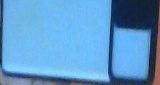

In [38]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

image_path = "/home/ajeet/codework/datasets/Training_Validation_Dataset_2024_Ajeet-20241107T105545Z-001/Training_Validation_Dataset_2024_Ajeet/test_2021/2021/mobile_output/g_top_74364.jpg"
image = Image.open(image_path).convert("RGB")
xmin, ymin, xmax, ymax = 160, 0, 320, 85
image = image.crop((xmin, ymin, xmax, ymax))
cropped_image_array = np.array(image)
print(cropped_image_array.shape)
image

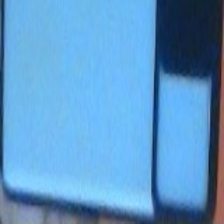

In [39]:
from PIL import Image
import matplotlib.pyplot as plt

# image_path = "/home/ajeet/codework/datasets/Training_Validation_Dataset_2024_Ajeet-20241107T105545Z-001/Training_Validation_Dataset_2024_Ajeet/mv_snap_cts_feb/Keshava_600001_mv_snap_23166.jpg"

# image = Image.open(image_path).convert("RGB")

# xmin, ymin, xmax, ymax = 259, 42, 289, 132

# cropped_image = image.crop((xmin, ymin, xmax, ymax))

# Resize the cropped image to 224x224 for MobileNetV2 input
resized_image = image.resize((224, 224))

# plt.imshow(resized_image)
# plt.axis('off')  # Hide the axes
# plt.show()
resized_image


In [30]:
from PIL import Image

def resize_and_pad_image(image, target_size=(224, 224)):
    aspect_ratio = image.width / image.height
    
    if aspect_ratio > 1:
        new_width = target_size[0]
        new_height = int(target_size[0] / aspect_ratio)
    else:
        new_height = target_size[1]
        new_width = int(target_size[1] * aspect_ratio)

    resized_image = image.resize((new_width, new_height), Image.LANCZOS)

    padded_image = Image.new("RGB", target_size, (255, 255, 255))  # Black padding
    padded_image
    padded_image.paste(resized_image, ((target_size[0] - new_width) // 2, (target_size[1] - new_height) // 2))

    return padded_image

image_path = "/home/ajeet/codework/datasets/Training_Validation_Dataset_2024_Ajeet-20241107T105545Z-001/Training_Validation_Dataset_2024_Ajeet/test_2021/2021/mobile_output/g_right_216102.jpg"
image = Image.open(image_path).convert("RGB")
xmin, ymin, xmax, ymax = 291,144,320,240

cropped_image = image.crop((xmin, ymin, xmax, ymax))

processed_image = resize_and_pad_image(cropped_image)

processed_image


AttributeError: module 'PIL.Image' has no attribute 'ANTIALIAS'

In [ ]:
import pandas as pd

csv_path = '/home/ajeet/codework/visionworkajeet/models/my_visionwork/models/clip/phone/bb_data_phone_classifier_only/balanced_all_merged_annotations.csv'  # Replace with the actual CSV path
df = pd.read_csv(csv_path)

image_path_to_remove = '/home/ajeet/codework/datasets/Training_Validation_Dataset_2024_Ajeet-20241107T105545Z-001/Training_Validation_Dataset_2024_Ajeet/mv_snap_cts_feb/Mahale_619798_mv_snap_25599.jpg'

df_filtered = df[df['Image Path'] != image_path_to_remove]
df_filtered.to_csv(csv_path, index=False)

print(f"Row with image path '{image_path_to_remove}' has been removed.")
